In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import bayesfm as bfm
import statsmodels.api as sm
from matplotlib.pyplot import plot_date

In [83]:
EBC = pd.read_csv("ebc_weigths.csv", index_col=0, parse_dates=True)
EBC_numeric = EBC.apply(pd.to_numeric, errors="coerce")
EBC_numeric

,A,A.1,AAF,AAL,AAL.1,AAP,AAPL,AAV,ABA,ABBV,...,YHOO,YUM,ZA,ZB,ZBH,ZBRA,ZE,ZION,ZRN,ZTS
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.001002,0.000000,0.0,0.001041,0.0,0.0,0.000000,0.0,0.002034,0.000000,...,0.0,0.000000,0.001633,0.001978,0.000000,0.000000,0.001902,0.0,0.0,0.000000
1967-02-28,0.001010,0.000000,0.0,0.001107,0.0,0.0,0.000000,0.0,0.001835,0.000000,...,0.0,0.000000,0.001137,0.002339,0.000000,0.000000,0.001531,0.0,0.0,0.000000
1967-03-31,0.000977,0.000000,0.0,0.001094,0.0,0.0,0.000000,0.0,0.001831,0.000000,...,0.0,0.000000,0.001183,0.002301,0.000000,0.000000,0.001581,0.0,0.0,0.000000
1967-04-30,0.001073,0.000000,0.0,0.001091,0.0,0.0,0.000000,0.0,0.001602,0.000000,...,0.0,0.000000,0.001270,0.002080,0.000000,0.000000,0.001695,0.0,0.0,0.000000
1967-05-31,0.001065,0.000000,0.0,0.001124,0.0,0.0,0.000000,0.0,0.001559,0.000000,...,0.0,0.000000,0.001312,0.001902,0.000000,0.000000,0.001555,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,0.000000,0.001612,0.0,0.001466,0.0,0.0,0.001720,0.0,0.000000,0.003488,...,0.0,0.002517,0.000000,0.000000,0.002524,0.001179,0.000000,0.0,0.0,0.001876
2024-09-30,0.000000,0.001674,0.0,0.001483,0.0,0.0,0.001680,0.0,0.000000,0.003865,...,0.0,0.002578,0.000000,0.000000,0.002521,0.001247,0.000000,0.0,0.0,0.001933
2024-10-31,0.000000,0.001701,0.0,0.000000,0.0,0.0,0.001715,0.0,0.000000,0.003699,...,0.0,0.002607,0.000000,0.000000,0.002493,0.001204,0.000000,0.0,0.0,0.001867


In [84]:
cap_data = pd.read_csv("sp500_market_caps.csv", index_col="date")
cap_data.head()
cap_data = cap_data * 1000
cap_data_numeric = cap_data.apply(pd.to_numeric, errors='coerce')
cap_data_numeric = cap_data_numeric.fillna(0)
weight_data = cap_data_numeric.div(cap_data_numeric.sum(axis=1), axis=0)
row_sums = weight_data.sum(axis=1)
print(row_sums.head())
weight_data

date
1960-01-29    1.0
1960-02-29    1.0
1960-03-31    1.0
1960-04-29    1.0
1960-05-31    1.0
dtype: float64


,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1960-01-29,0.000291,0.000336,0.000111,0.0,0.001253,0.000000,0.000000,0.0,0.001330,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-02-29,0.000297,0.000339,0.000110,0.0,0.001204,0.000000,0.000000,0.0,0.001387,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-03-31,0.000284,0.000305,0.000107,0.0,0.001269,0.000000,0.000000,0.0,0.001384,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-04-29,0.000265,0.000293,0.000109,0.0,0.001226,0.000000,0.000000,0.0,0.001422,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1960-05-31,0.000267,0.000277,0.000101,0.0,0.001217,0.000000,0.000000,0.0,0.001444,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-30,0.000000,0.000000,0.000000,0.0,0.000000,0.007886,0.062798,0.0,0.000000,0.000478,...,0.0,0.015402,0.000787,0.000370,0.001188,0.0,0.000191,0.0,0.000435,0.013853
2024-09-30,0.000000,0.000000,0.000000,0.0,0.000000,0.009342,0.063290,0.0,0.000000,0.000479,...,0.0,0.015940,0.000750,0.000368,0.001175,0.0,0.000189,0.0,0.000424,0.016600
2024-10-31,0.000000,0.000000,0.000000,0.0,0.000000,0.009296,0.060384,0.0,0.000000,0.000488,...,0.0,0.015848,0.000775,0.000352,0.001204,0.0,0.000199,0.0,0.000447,0.016030


In [85]:
weight_data.index = pd.to_datetime(weight_data.index, errors="coerce")
EBC.index = pd.to_datetime(EBC.index, errors="coerce")

# Align on intersection of indexes
common_index = weight_data.index.intersection(EBC.index)

weight_data_aligned = weight_data.loc[common_index]
EBC_aligned = EBC.loc[common_index]

# Align columns on intersection too
common_cols = weight_data_aligned.columns.intersection(EBC_aligned.columns)

weight_data_aligned = weight_data_aligned[common_cols]
EBC_aligned = EBC_aligned[common_cols]

In [92]:
print(common_index)

DatetimeIndex(['1967-01-31', '1967-02-28', '1967-03-31', '1967-05-31',
               '1967-06-30', '1967-07-31', '1967-08-31', '1967-10-31',
               '1967-11-30', '1968-01-31',
               ...
               '2023-10-31', '2023-11-30', '2024-01-31', '2024-02-29',
               '2024-04-30', '2024-05-31', '2024-07-31', '2024-09-30',
               '2024-10-31', '2024-12-31'],
              dtype='datetime64[ns]', name='date', length=486, freq=None)


In [86]:
SPC_EBC_weights = weight_data_aligned - EBC_aligned
SPC_EBC_weights

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,-0.000878,-0.001150,-0.001293,0.0,-0.000639,0.000000,0.000000,0.0,-0.001869,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1967-02-28,-0.000909,-0.001091,-0.001281,0.0,-0.000657,0.000000,0.000000,0.0,-0.004373,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1967-03-31,-0.000876,-0.001053,-0.001228,0.0,-0.000581,0.000000,0.000000,0.0,-0.004281,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1967-05-31,-0.000684,-0.001168,-0.001260,0.0,-0.000569,0.000000,0.000000,0.0,-0.003215,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1967-06-30,-0.000759,-0.001278,-0.001266,0.0,-0.000524,0.000000,0.000000,0.0,-0.002525,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31,0.000000,0.000000,0.000000,0.0,0.000000,0.005526,0.065220,0.0,0.000000,-0.000723,...,0.0,0.011928,-0.001406,-0.002905,-0.000760,0.0,-0.000783,0.0,-0.003167,0.011241
2024-07-31,0.000000,0.000000,0.000000,0.0,0.000000,0.006451,0.062444,0.0,0.000000,-0.000802,...,0.0,0.013960,-0.001414,-0.003182,-0.001037,0.0,-0.000895,0.0,-0.003411,0.014254
2024-09-30,0.000000,0.000000,0.000000,0.0,0.000000,0.007859,0.061348,0.0,0.000000,-0.000855,...,0.0,0.014449,-0.001558,-0.003759,-0.000775,0.0,-0.000936,0.0,-0.003488,0.015569


In [87]:
# long-only (positive weights)
long_only = SPC_EBC_weights.clip(lower=0)

# short-only (negative weights, keep as negative)
short_only = -SPC_EBC_weights.clip(upper=0)

long_only


,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-02-28,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-03-31,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-05-31,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1967-06-30,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31,0.0,0.0,0.0,0.0,0.0,0.005526,0.065220,0.0,0.0,0.0,...,0.0,0.011928,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011241
2024-07-31,0.0,0.0,0.0,0.0,0.0,0.006451,0.062444,0.0,0.0,0.0,...,0.0,0.013960,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.014254
2024-09-30,0.0,0.0,0.0,0.0,0.0,0.007859,0.061348,0.0,0.0,0.0,...,0.0,0.014449,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.015569


In [73]:
short_only

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,0.000878,0.001150,0.001293,-0.0,0.000639,-0.0,-0.0,-0.0,0.001869,-0.000000,...,-0.0,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0
1967-02-28,0.000909,0.001091,0.001281,-0.0,0.000657,-0.0,-0.0,-0.0,0.004373,-0.000000,...,-0.0,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0
1967-03-31,0.000876,0.001053,0.001228,-0.0,0.000581,-0.0,-0.0,-0.0,0.004281,-0.000000,...,-0.0,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0
1967-05-31,0.000684,0.001168,0.001260,-0.0,0.000569,-0.0,-0.0,-0.0,0.003215,-0.000000,...,-0.0,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0
1967-06-30,0.000759,0.001278,0.001266,-0.0,0.000524,-0.0,-0.0,-0.0,0.002525,-0.000000,...,-0.0,-0.0,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.000000,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.0,-0.0,-0.000000,0.000723,...,-0.0,-0.0,0.001406,0.002905,0.000760,-0.0,0.000783,-0.0,0.003167,-0.0
2024-07-31,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.0,-0.0,-0.000000,0.000802,...,-0.0,-0.0,0.001414,0.003182,0.001037,-0.0,0.000895,-0.0,0.003411,-0.0
2024-09-30,-0.000000,-0.000000,-0.000000,-0.0,-0.000000,-0.0,-0.0,-0.0,-0.000000,0.000855,...,-0.0,-0.0,0.001558,0.003759,0.000775,-0.0,0.000936,-0.0,0.003488,-0.0


In [74]:
print(weight_data_aligned.shape, long_only.shape)
print(weight_data_aligned.index.equals(long_only.index))
print(weight_data_aligned.columns.equals(long_only.columns))

(486, 1596) (486, 1596)
True
True


In [80]:
long_portfolio = long_only
short_portfolio = short_only


In [115]:
long_portfolio = long_portfolio.div(long_portfolio.sum(axis=1), axis=0)

In [116]:
short_portfolio = short_portfolio.div(short_portfolio.sum(axis=1), axis=0)

In [117]:
return_data = pd.read_csv("sp500_returns_with_tickers.csv", index_col=0, parse_dates=True)
return_data

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1960-01-29,0.005155,-0.015000,-0.020785,NaN,-0.092262,NaN,NaN,NaN,-0.020833,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-02-29,0.046154,0.017767,0.009434,NaN,-0.021312,NaN,NaN,NaN,0.053192,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-03-31,-0.059553,-0.100249,-0.047170,NaN,0.038851,NaN,NaN,NaN,-0.005387,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-04-29,-0.081794,-0.056180,0.000000,NaN,-0.050407,NaN,NaN,NaN,0.010274,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1960-05-31,0.048851,-0.029762,-0.034654,NaN,0.029110,NaN,NaN,NaN,0.044068,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-30,NaN,NaN,NaN,NaN,NaN,0.013195,-0.001100,NaN,NaN,-0.071535,...,NaN,0.013319,0.042292,-0.310823,0.321675,NaN,0.005460,NaN,0.122718,-0.077391
2024-09-30,NaN,NaN,NaN,NaN,NaN,0.206030,0.031548,NaN,NaN,0.038948,...,NaN,0.062707,-0.016385,0.019284,0.010950,NaN,0.015013,NaN,-0.002580,0.221942
2024-10-31,NaN,NaN,NaN,NaN,NaN,-0.012676,-0.055659,NaN,NaN,0.008538,...,NaN,-0.015826,0.025228,-0.046589,0.014313,NaN,0.041981,NaN,0.042466,-0.045025


In [118]:
common_idx = return_data.index.intersection(long_portfolio.index).intersection(short_portfolio.index)
common_cols = return_data.columns.intersection(long_portfolio.columns).intersection(short_portfolio.columns)

# Step 2: align all three
returns_aligned = return_data.loc[common_idx, common_cols]
long_aligned = long_portfolio.loc[common_idx, common_cols]
short_aligned = short_portfolio.loc[common_idx, common_cols]

long_aligned


,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
date,,,,,,,,,,,,,,,,,,,,,
1967-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31,NaN,NaN,NaN,NaN,NaN,0.009834,0.094198,NaN,NaN,NaN,...,NaN,0.018881,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.017339
2024-07-31,NaN,NaN,NaN,NaN,NaN,0.011418,0.092393,NaN,NaN,NaN,...,NaN,0.022223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.022028
2024-09-30,NaN,NaN,NaN,NaN,NaN,0.013495,0.091430,NaN,NaN,NaN,...,NaN,0.023027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.023980


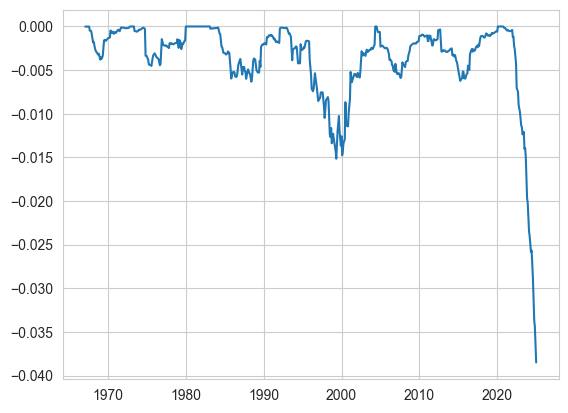

In [211]:
sum_spc_ebc_weights = SPC_EBC_weights.sum(axis=1)
plt.plot(sum_spc_ebc_weights)

In [184]:

returns_aligned = returns_aligned.fillna(0)
long_returns = (returns_aligned * long_aligned).sum(axis=1)
short_returns = (returns_aligned * short_aligned).sum(axis=1)
SPC_EBC_returns = (returns_aligned * SPC_EBC_weights).sum(axis=1)


In [185]:
portfolio_returns = pd.DataFrame({
    "Long_Portfolio": long_returns,
    "Short_Portfolio": short_returns,
    "SPC_EBC_returns": SPC_EBC_returns,
})

In [186]:
portfolio_returns.tail(100)

,Long_Portfolio,Short_Portfolio,SPC_EBC_returns
date,,,
2013-02-28,0.013717,0.017790,-0.006419
2013-04-30,0.022832,0.021782,-0.001950
2013-05-31,0.030503,0.016904,0.021079
2013-07-31,0.053372,0.054335,0.002298
2013-09-30,0.032607,0.036540,0.001347
...,...,...,...
2024-05-31,0.067344,0.025812,0.035182
2024-07-31,0.005393,0.051198,-0.029358
2024-09-30,0.028033,0.014982,0.007259


In [122]:
sp_returns = pd.read_csv("sp500_capweighted_returns.csv", index_col=0, parse_dates=True)

In [123]:
common_idx = return_data.index.intersection(long_portfolio.index).intersection(short_portfolio.index).intersection(sp_returns.index)
common_cols = return_data.columns.intersection(long_portfolio.columns).intersection(short_portfolio.columns)

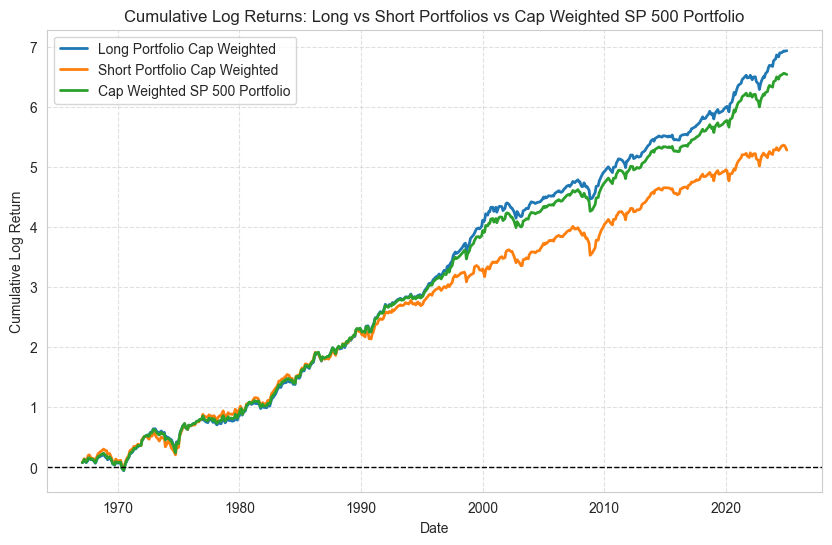

In [209]:
import numpy as np
import matplotlib.pyplot as plt

sp_returns = sp_returns.loc[common_idx]

# Compute cumulative log returns
cum_log_long = np.log1p(long_returns).cumsum()
cum_log_short = np.log1p(short_returns).cumsum()
cum_sp_500 = np.log1p(sp_returns).cumsum()

# Plot
plt.figure(figsize=(10,6))
plt.plot(cum_log_long, label="Long Portfolio Cap Weighted", linewidth=2)
plt.plot(cum_log_short, label="Short Portfolio Cap Weighted", linewidth=2)
plt.plot(cum_sp_500, label="Cap Weighted SP 500 Portfolio", linewidth=2)
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title("Cumulative Log Returns: Long vs Short Portfolios vs Cap Weighted SP 500 Portfolio")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


In [162]:
import numpy as np
import statsmodels.api as sm
import pandas as pd
from tqdm import tqdm

def run_fmb_factor(sp500, factor_returns, ROLLING_WINDOW=36, MIN_OBS=10):
    """Run two pass regression using Cap - EBC as factor"""

    asset_cols = sp500.columns
    combined = sp500.join(factor_returns, how="inner")  # ensure alignment

    betas_dict = {asset: [] for asset in asset_cols}
    beta_dates = []

    # first pass
    print("Running first-pass rolling regressions...")
    # stop one row early so that a "next period" always exists
    for end_date in tqdm(combined.index[ROLLING_WINDOW-1 : -1], desc="Time-series betas"):
        pos = combined.index.get_loc(end_date)
        next_date = combined.index[pos + 1]   # month whose return we'll predict

        start_idx = pos - (ROLLING_WINDOW - 1)
        window_dates = combined.index[start_idx : start_idx + ROLLING_WINDOW]

        for asset in asset_cols:
            y = sp500.loc[window_dates, asset]
            x = factor_returns.loc[window_dates]
            data = pd.concat([y, x], axis=1).dropna()
            if len(data) < MIN_OBS:
                betas_dict[asset].append(np.nan)
                continue

            Y = data[asset]
            X = sm.add_constant(data[factor_returns.name])
            res = sm.OLS(Y, X).fit()

            betas_dict[asset].append(res.params[factor_returns.name])

        # append betas for the NEXT month so they line up with next month's returns
        beta_dates.append(next_date)

    betas_df = pd.DataFrame(betas_dict, index=beta_dates)

    #second pass
    print("Running second-pass cross-sectional regressions...")
    lambda_vals = []
    for date in tqdm(betas_df.index, desc="Cross-sectional λ"):
        if date not in sp500.index:
            continue
        returns_t = sp500.loc[date].dropna()
        betas_t = betas_df.loc[date].dropna()

        common_assets = returns_t.index.intersection(betas_t.index)
        if len(common_assets) < MIN_OBS:
            continue

        y_cs = returns_t.loc[common_assets]
        X_cs = sm.add_constant(betas_t.loc[common_assets])
        res_cs = sm.OLS(y_cs, X_cs).fit()

        lambda_vals.append(res_cs.params[1])  # store only the slope


    lambda_series = pd.Series(lambda_vals, index=betas_df.index[:len(lambda_vals)],
                              name=f"lambda_{factor_returns.name}")

    T = len(lambda_series.dropna())
    lambda_mean = lambda_series.mean()
    lambda_std  = lambda_series.std(ddof=1)


    fmb_tstat = lambda_mean / (lambda_std / np.sqrt(T))

    return betas_df, lambda_series, fmb_tstat

In [163]:

long_returns.name = "Long_Factor"
short_returns.name = "Short_Factor"


betas_long, lambdas_long, tstats_long = run_fmb_factor(returns_aligned, long_returns)
betas_short, lambdas_short, tstats_short = run_fmb_factor(returns_aligned, short_returns)

Running first-pass rolling regressions...


Time-series betas: 100%|██████████| 450/450 [15:20<00:00,  2.05s/it]  


Running second-pass cross-sectional regressions...


Cross-sectional λ:   0%|          | 0/450 [00:00<?, ?it/s]/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_10782/3087531044.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda_vals.append(res_cs.params[1])  # store only the slope
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_10782/3087531044.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda_vals.append(res_cs.params[1])  # store only the slope
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_10782/3087531044.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, intege

Running first-pass rolling regressions...


Time-series betas: 100%|██████████| 450/450 [11:46<00:00,  1.57s/it]


Running second-pass cross-sectional regressions...


Cross-sectional λ:   0%|          | 0/450 [00:00<?, ?it/s]/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_10782/3087531044.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda_vals.append(res_cs.params[1])  # store only the slope
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_10782/3087531044.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda_vals.append(res_cs.params[1])  # store only the slope
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_10782/3087531044.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, intege

In [188]:
SPC_EBC_returns.name = "SPC_EBC_Returns"
betas_SPC_EBC, lambdas_SPC_EBC, tstats_SPC_EBC = run_fmb_factor(returns_aligned, SPC_EBC_returns)

Running first-pass rolling regressions...


Time-series betas: 100%|██████████| 450/450 [11:30<00:00,  1.53s/it]


Running second-pass cross-sectional regressions...


Cross-sectional λ:   0%|          | 0/450 [00:00<?, ?it/s]/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_10782/3087531044.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda_vals.append(res_cs.params[1])  # store only the slope
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_10782/3087531044.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda_vals.append(res_cs.params[1])  # store only the slope
/var/folders/rd/6pjhbndj3_xbc_vx64hj0zh00000gn/T/ipykernel_10782/3087531044.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, intege

In [189]:
print(tstats_long)

4.084567426817526


In [190]:
print(tstats_short)

4.253622211739812


In [191]:
print(tstats_SPC_EBC)

-2.4058448679438467


In [210]:
import pandas as pd

# create a dictionary with your t-stats
tstats_dict = {
    "Portfolio": ["Long", "Short", "SPC-EBC"],
    "t-stat": [tstats_long, tstats_short, tstats_SPC_EBC]
}

# convert to DataFrame
tstats_df = pd.DataFrame(tstats_dict)

# optional: round for prettier display
tstats_df["t-stat"] = tstats_df["t-stat"].round(3)

# print table
print(tstats_df)


  Portfolio  t-stat
0      Long   4.085
1     Short   4.254
2   SPC-EBC  -2.406


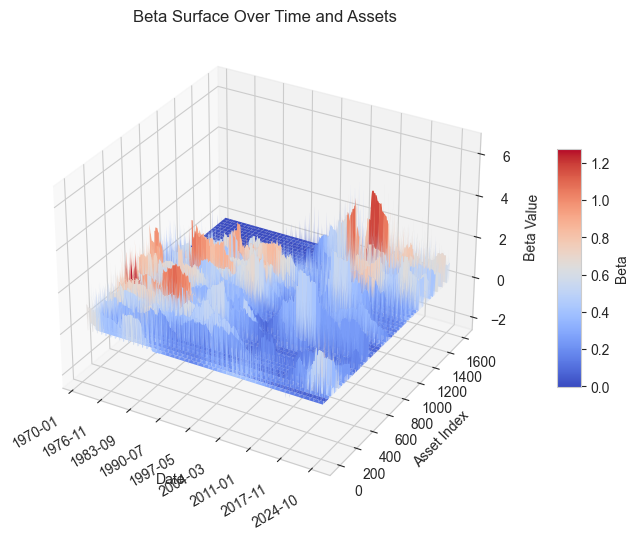

In [165]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib.dates as mdates
import numpy as np

# convert dates to numeric for plotting
dates_num = mdates.date2num(betas_long.index)
assets_num = np.arange(len(betas_long.columns))

# create meshgrid
X, Y = np.meshgrid(dates_num, assets_num)
Z = betas_long.values.T  # shape must match meshgrid (assets x dates)

# create 3D figure
fig = plt.figure(figsize=(14,7))
ax = fig.add_subplot(111, projection='3d')

# plot the surface
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, edgecolor='none')

# axis labels
ax.set_xlabel("Date")
ax.set_ylabel("Asset Index")
ax.set_zlabel("Beta Value")
ax.set_title("Beta Surface Over Time and Assets")

# format dates nicely
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()

# add colorbar
fig.colorbar(surf, shrink=0.5, aspect=10, label="Beta")

plt.show()


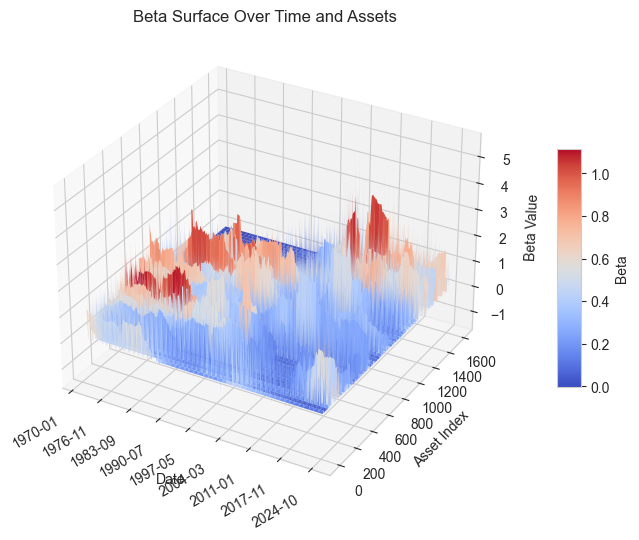

In [166]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import matplotlib.dates as mdates
import numpy as np

# convert dates to numeric for plotting
dates_num = mdates.date2num(betas_short.index)
assets_num = np.arange(len(betas_short.columns))

# create meshgrid
X, Y = np.meshgrid(dates_num, assets_num)
Z = betas_short.values.T  # shape must match meshgrid (assets x dates)

# create 3D figure
fig = plt.figure(figsize=(14,7))
ax = fig.add_subplot(111, projection='3d')

# plot the surface
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, edgecolor='none')

# axis labels
ax.set_xlabel("Date")
ax.set_ylabel("Asset Index")
ax.set_zlabel("Beta Value")
ax.set_title("Beta Surface Over Time and Assets")

# format dates nicely
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate()

# add colorbar
fig.colorbar(surf, shrink=0.5, aspect=10, label="Beta")

plt.show()

In [167]:
lambdas_long

1971-09-30   -0.011253
1971-11-30   -0.015391
1971-12-31    0.080147
1972-01-31    0.028668
1972-02-29    0.018017
                ...   
2024-05-31    0.019163
2024-07-31    0.032641
2024-09-30    0.022096
2024-10-31   -0.012818
2024-12-31   -0.048632
Name: lambda_Long_Factor, Length: 450, dtype: float64

In [168]:
betas_long

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
1971-09-30,1.306138,0.527410,0.648120,0.0,1.756379,0.000000,0.000000,0.0,0.625569,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1971-11-30,1.266898,0.417979,0.544421,0.0,1.789130,0.000000,0.000000,0.0,0.725922,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1971-12-31,1.267052,0.418435,0.542237,0.0,1.788805,0.000000,0.000000,0.0,0.723622,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1972-01-31,1.147818,0.368564,0.698606,0.0,1.800594,0.000000,0.000000,0.0,0.801200,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1972-02-29,1.185172,0.350741,0.682405,0.0,1.854341,0.000000,0.000000,0.0,0.727492,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31,0.000000,0.000000,0.000000,0.0,0.000000,0.976924,0.916021,0.0,0.000000,1.397246,...,0.0,1.121635,0.893638,0.429620,0.770120,0.0,0.865822,0.0,0.696189,0.735381
2024-07-31,0.000000,0.000000,0.000000,0.0,0.000000,1.030681,0.977800,0.0,0.000000,1.387862,...,0.0,1.055046,0.912483,0.471043,0.785768,0.0,1.016511,0.0,0.498256,0.768820
2024-09-30,0.000000,0.000000,0.000000,0.0,0.000000,1.083180,0.987774,0.0,0.000000,1.357725,...,0.0,1.081315,0.955796,0.350473,0.849949,0.0,1.091601,0.0,0.425846,0.868058
2024-10-31,0.000000,0.000000,0.000000,0.0,0.000000,1.089527,0.980192,0.0,0.000000,1.357465,...,0.0,1.077768,0.958476,0.351566,0.853436,0.0,1.092243,0.0,0.438688,0.877689


In [169]:
betas_short

,ACF,ABK,AMT,JAVA,AN,ORCL,MSFT,SDS,AYE,TROW,...,CFN,AVGO,VRSK,DG.2,FTNT,VAL,GNRC,QEP,CBOE,TSLA
1971-09-30,1.189416,0.572753,0.567900,0.0,1.535748,0.000000,0.000000,0.0,0.582877,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1971-11-30,1.160486,0.485046,0.477636,0.0,1.570535,0.000000,0.000000,0.0,0.673298,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1971-12-31,1.165578,0.486102,0.498541,0.0,1.558418,0.000000,0.000000,0.0,0.689766,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1972-01-31,1.046319,0.424814,0.642703,0.0,1.558081,0.000000,0.000000,0.0,0.745277,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
1972-02-29,1.049761,0.414092,0.628146,0.0,1.560325,0.000000,0.000000,0.0,0.703695,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31,0.000000,0.000000,0.000000,0.0,0.000000,0.819444,0.617287,0.0,0.000000,1.299264,...,0.0,0.912491,0.696971,0.439358,0.644760,0.0,0.612635,0.0,0.701598,0.389115
2024-07-31,0.000000,0.000000,0.000000,0.0,0.000000,0.971428,0.714277,0.0,0.000000,1.389052,...,0.0,0.894240,0.708364,0.566405,0.765478,0.0,0.827485,0.0,0.506671,0.454302
2024-09-30,0.000000,0.000000,0.000000,0.0,0.000000,0.978759,0.624315,0.0,0.000000,1.329324,...,0.0,0.858157,0.680721,0.399337,0.777712,0.0,0.985347,0.0,0.471291,0.597524
2024-10-31,0.000000,0.000000,0.000000,0.0,0.000000,0.981301,0.635035,0.0,0.000000,1.333636,...,0.0,0.864904,0.677490,0.399821,0.774837,0.0,0.987617,0.0,0.456647,0.596227


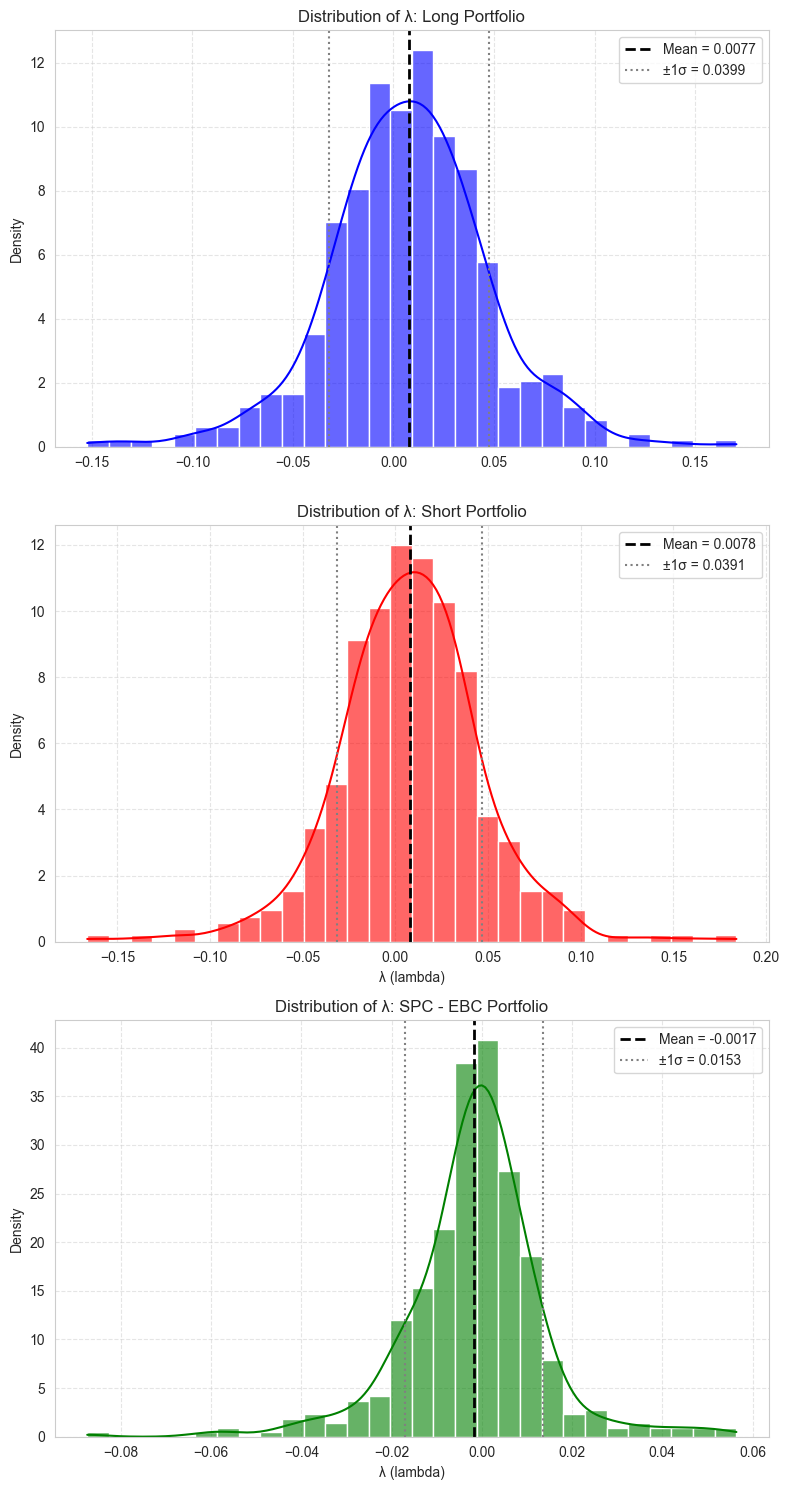

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 15))

# --- Long portfolio ---
plt.subplot(3, 1, 1)
sns.histplot(lambdas_long, bins=30, kde=True, color="blue", stat="density", alpha=0.6)

mean_long = lambdas_long.mean()
std_long = lambdas_long.std()

plt.axvline(mean_long, color="black", linestyle="--", linewidth=2, label=f"Mean = {mean_long:.4f}")
plt.axvline(mean_long - std_long, color="gray", linestyle=":", linewidth=1.5, label=f"±1σ = {std_long:.4f}")
plt.axvline(mean_long + std_long, color="gray", linestyle=":", linewidth=1.5)

plt.title("Distribution of λ: Long Portfolio")
plt.xlabel("")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# --- Short portfolio ---
plt.subplot(3, 1, 2)
sns.histplot(lambdas_short, bins=30, kde=True, color="red", stat="density", alpha=0.6)

mean_short = lambdas_short.mean()
std_short = lambdas_short.std()

plt.axvline(mean_short, color="black", linestyle="--", linewidth=2, label=f"Mean = {mean_short:.4f}")
plt.axvline(mean_short - std_short, color="gray", linestyle=":", linewidth=1.5, label=f"±1σ = {std_short:.4f}")
plt.axvline(mean_short + std_short, color="gray", linestyle=":", linewidth=1.5)

plt.title("Distribution of λ: Short Portfolio")
plt.xlabel("λ (lambda)")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# --- SPC - EBC portfolio ---
plt.subplot(3, 1, 3)
sns.histplot(lambdas_SPC_EBC, bins=30, kde=True, color="green", stat="density", alpha=0.6)

mean_spc_ebc = lambdas_SPC_EBC.mean()
std_spc_ebc = lambdas_SPC_EBC.std()

plt.axvline(mean_spc_ebc, color="black", linestyle="--", linewidth=2, label=f"Mean = {mean_spc_ebc:.4f}")
plt.axvline(mean_spc_ebc - std_spc_ebc, color="gray", linestyle=":", linewidth=1.5, label=f"±1σ = {std_spc_ebc:.4f}")
plt.axvline(mean_spc_ebc + std_spc_ebc, color="gray", linestyle=":", linewidth=1.5)

plt.title("Distribution of λ: SPC - EBC Portfolio")
plt.xlabel("λ (lambda)")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()



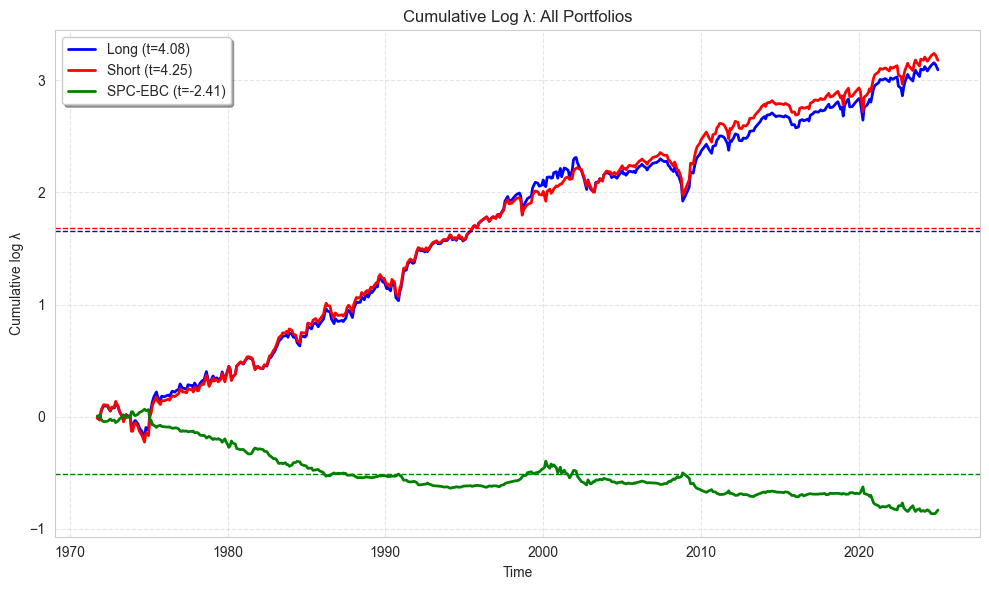

In [201]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

# cumulative log λ
cum_log_long = np.cumsum(np.log1p(lambdas_long))
cum_log_short = np.cumsum(np.log1p(lambdas_short))
cum_log_spc_ebc = np.cumsum(np.log1p(lambdas_SPC_EBC))

# plot all three
plt.plot(cum_log_long, color="blue", linewidth=2, label=f"Long (t={tstats_long:.2f})")
plt.plot(cum_log_short, color="red", linewidth=2, label=f"Short (t={tstats_short:.2f})")
plt.plot(cum_log_spc_ebc, color="green", linewidth=2, label=f"SPC-EBC (t={tstats_SPC_EBC:.2f})")

# optional mean lines (horizontal)
plt.axhline(np.mean(cum_log_long), color="blue", linestyle="--", linewidth=1)
plt.axhline(np.mean(cum_log_short), color="red", linestyle="--", linewidth=1)
plt.axhline(np.mean(cum_log_spc_ebc), color="green", linestyle="--", linewidth=1)

plt.title("Cumulative Log λ: All Portfolios")
plt.xlabel("Time")
plt.ylabel("Cumulative log λ")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()


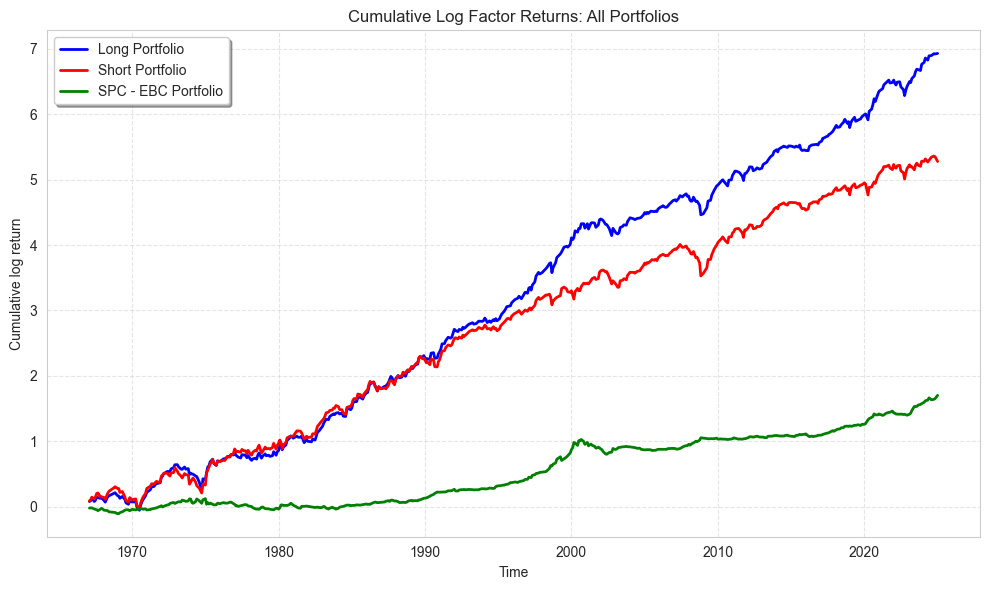

In [204]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

# cumulative log factor returns
cum_log_long = np.cumsum(np.log1p(long_returns))
cum_log_short = np.cumsum(np.log1p(short_returns))
cum_log_spc_ebc = np.cumsum(np.log1p(SPC_EBC_returns))

# plot all three on the same axes
plt.plot(cum_log_long, color="blue", linewidth=2, label="Long Portfolio")
plt.plot(cum_log_short, color="red", linewidth=2, label="Short Portfolio")
plt.plot(cum_log_spc_ebc, color="green", linewidth=2, label="SPC - EBC Portfolio")

plt.title("Cumulative Log Factor Returns: All Portfolios")
plt.xlabel("Time")
plt.ylabel("Cumulative log return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()



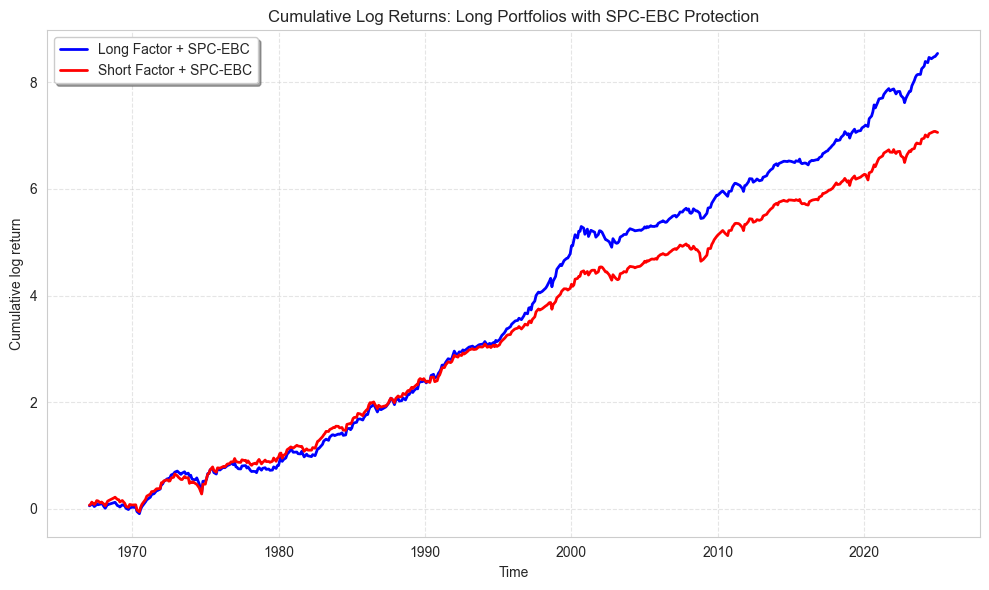

In [205]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

# hedged "long-long" style portfolios
long_long = long_returns + SPC_EBC_returns
short_long = short_returns + SPC_EBC_returns

# cumulative log returns
cum_log_long_long = np.cumsum(np.log1p(long_long))
cum_log_short_long = np.cumsum(np.log1p(short_long))

# plot
plt.plot(cum_log_long_long, color="blue", linewidth=2, label="Long Factor + SPC-EBC")
plt.plot(cum_log_short_long, color="red", linewidth=2, label="Short Factor + SPC-EBC")

plt.title("Cumulative Log Returns: Long Portfolios with SPC-EBC Protection")
plt.xlabel("Time")
plt.ylabel("Cumulative log return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()


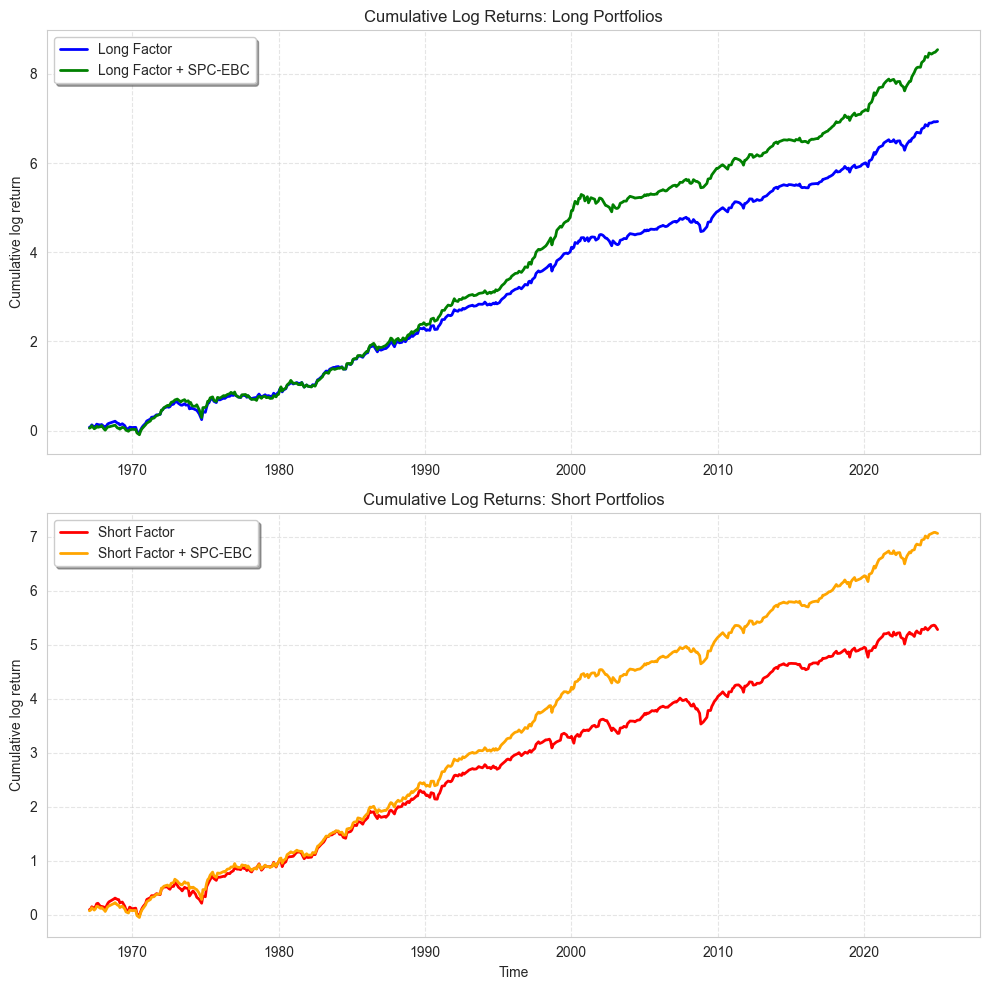

In [206]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,10))

# --- Top subplot: Long vs Long+SPC-EBC ---
plt.subplot(2,1,1)
cum_log_long = np.cumsum(np.log1p(long_returns))
cum_log_long_long = np.cumsum(np.log1p(long_returns + SPC_EBC_returns))

plt.plot(cum_log_long, color="blue", linewidth=2, label="Long Factor")
plt.plot(cum_log_long_long, color="green", linewidth=2, label="Long Factor + SPC-EBC")
plt.title("Cumulative Log Returns: Long Portfolios")
plt.ylabel("Cumulative log return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True, shadow=True)

# --- Bottom subplot: Short vs Short+SPC-EBC ---
plt.subplot(2,1,2)
cum_log_short = np.cumsum(np.log1p(short_returns))
cum_log_short_long = np.cumsum(np.log1p(short_returns + SPC_EBC_returns))

plt.plot(cum_log_short, color="red", linewidth=2, label="Short Factor")
plt.plot(cum_log_short_long, color="orange", linewidth=2, label="Short Factor + SPC-EBC")
plt.title("Cumulative Log Returns: Short Portfolios")
plt.xlabel("Time")
plt.ylabel("Cumulative log return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True, shadow=True)

plt.tight_layout()
plt.show()
